# Channel Ablation: What the Potassium Current Does

To build intuition for what each conductance contributes, we can **ablate** a channel — set its maximal conductance to zero — and watch how the dynamics change. Here we compare an intact HH neuron against one whose delayed-rectifier potassium current has been removed. Potassium repolarizes the membrane after a spike, so removing it should abolish normal, repetitive spiking.

In [1]:
import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import braincell

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A neuron with a tunable potassium conductance

We expose the potassium maximal conductance `gK` as a constructor argument so we can instantiate an intact cell and an ablated cell (`gK = 0`) from the same class.

In [2]:
class HH(braincell.SingleCompartment):
    def __init__(self, size, gK=36. * (u.mS / u.cm ** 2), solver='exp_euler'):
        super().__init__(size, V_th=20. * u.mV, solver=solver)
        self.na = braincell.ion.SodiumFixed(size, E=50. * u.mV)
        self.na.add(INa=braincell.channel.Na_HH1952(size))
        self.k = braincell.ion.PotassiumFixed(size, E=-77. * u.mV)
        self.k.add(IK=braincell.channel.K_HH1952(size, g_max=gK))
        self.IL = braincell.channel.IL(size, E=-54.387 * u.mV,
                                       g_max=0.03 * (u.mS / u.cm ** 2))

## Simulate intact vs. ablated

Both cells receive the same 5 uA/cm^2 current. The intact cell uses the default potassium conductance; the ablated cell sets `gK = 0`.

In [3]:
intact = HH(1)
ablated = HH(1, gK=0. * (u.mS / u.cm ** 2))
intact.init_state()
ablated.init_state()

I = 5. * u.uA / u.cm ** 2

def step(t):
    with brainstate.environ.context(t=t):
        intact.update(I)
        ablated.update(I)
    return intact.V.value, ablated.V.value

with brainstate.environ.context(dt=0.01 * u.ms):
    times = u.math.arange(0. * u.ms, 80. * u.ms, brainstate.environ.get_dt())
    v_intact, v_ablated = brainstate.transform.for_loop(step, times)

## Compare the traces

The intact neuron fires a clean spike train; without potassium the membrane cannot repolarize and gets stuck in a depolarized state (depolarization block).

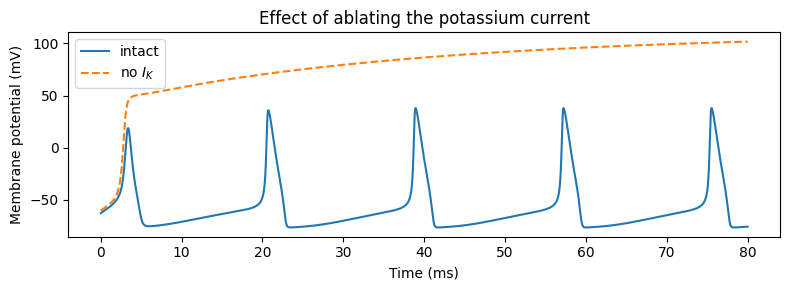

In [4]:
plt.figure(figsize=(8, 3))
plt.plot(times / u.ms, u.math.squeeze(v_intact) / u.mV, label='intact')
plt.plot(times / u.ms, u.math.squeeze(v_ablated) / u.mV, label='no $I_K$', linestyle='--')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.title('Effect of ablating the potassium current')
plt.legend()
plt.tight_layout()
plt.show()